# Proyecto Final  
## Sistema de Recuperación de Información Multimodal con RAG  
**Asignatura:** Recuperación de Información  
**Realizado por:** Bautista Alexis, Correa Adrian, Yunga Bryan  
**Fecha de entrega:** 22 de julio de 2026

### **Objetivo**
Diseñar e implementar un sistema de Recuperación de Información Multimodal capaz de responder consultas conversacionales sobre un corpus compuesto por texto e imágenes.

El sistema deberá utilizar modelos de embeddings multimodales para representar el contenido del corpus, almacenar dichas representaciones en una base de datos vectorial, recuperar los elementos más relevantes para una consulta y utilizarlos como contexto para un sistema de Retrieval-Augmented Generation (RAG).

El objetivo del proyecto es integrar los conceptos estudiados durante el curso en un sistema moderno de Recuperación de Información, combinando recuperación multimodal, bases de datos vectoriales, modelos de lenguaje, interfaces conversacionales y evaluación experimental.

## Alcance y funcionalidades mínimas

### a. Preparación del corpus

El sistema trabaja sobre un corpus multimodal compuesto por documentos que incluye información textual e imágenes.

En este aparatado se: 

- carga el corpus;
- procesa el texto cuando sea necesario;
- asocia correctamente cada imagen con la información textual correspondiente.

Cargando URLs de imágenes (Crossing Minds)...
Cargando textos originales (Amazon ESCI)...
Total de productos fusionados con texto e imagen URL: 35839
Descargando y asociando 5 muestras...
Registros multimodales listos: 5
--- RESULTADO DE LA ASOCIACIÓN MULTIMODAL ---
ID del Producto: B07GNHF45Z
Texto procesado (Contexto): 'cleaver knife - imarku 7 inch meat cleaver - 7cr17mov german high carbon stainless steel butcher knife with ergonomic handle for home kitchen and rest...'
Objeto de Imagen: <class 'PIL.Image.Image'> - Tamaño: (679, 747)


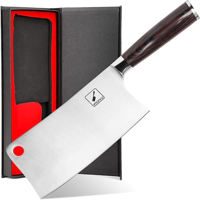

In [1]:
from preparar_corpus import cargar_y_fusionar_corpus, asociar_multimodal

# Cargar y fusionar el corpus
df_corpus = cargar_y_fusionar_corpus(split="train")
print(f"Total de productos fusionados con texto e imagen URL: {len(df_corpus)}")

# Procesar texto y asociar imágenes
# Extraemos una muestra pequeña para no saturar las descargas en la fase de prueba
corpus_preparado = asociar_multimodal(df_corpus, num_muestras=5)
print(f"Registros multimodales listos: {len(corpus_preparado)}")

# Mostrar resultados
if corpus_preparado:
    muestra = corpus_preparado[0]
    print("--- RESULTADO DE LA ASOCIACIÓN MULTIMODAL ---")
    print(f"ID del Producto: {muestra['product_id']}")
    # Aquí es donde veremos el texto real que usará el RAG
    print(f"Texto procesado (Contexto): '{muestra['texto'][:150]}...'") 
    print(f"Objeto de Imagen: {type(muestra['imagen'])} - Tamaño: {muestra['imagen'].size}")
    
    # Previsualización rápida
    display(muestra['imagen'].resize((200, 200)))
else:
    print("No se pudieron asociar imágenes válidas en esta muestra.")

### b. Construcción de representaciones vectoriales

En esta etapa, utilizamos el modelo multimodal **CLIP** (`openai/clip-vit-base-patch32`) para proyectar tanto el texto como las imágenes del corpus en un mismo espacio vectorial continuo. Para cada documento, extraemos las características visuales y textuales, las promediamos y las normalizamos (L2) creando un único embedding multimodal. Asimismo, el modelo codifica las consultas de texto del usuario en este mismo espacio, permitiendo comparar semánticamente la intención de búsqueda contra todo el catálogo.

In [2]:
from construir_embeddings import ConstructorEmbeddings

# Instanciamos el modelo CLIP (esto descargará los pesos si es la primera vez)
# Cumple: "generar embeddings para todos los documentos del corpus" y "consultas"
constructor = ConstructorEmbeddings()

# Generamos la matriz matemática
print("Extrayendo características multimodales...")
matriz_embeddings, metadatos = constructor.generar_matriz_corpus(corpus_preparado, batch_size=16)

print(f"Forma de la matriz de embeddings: {matriz_embeddings.shape}")

Cargando modelo CLIP 'openai/clip-vit-base-patch32' en cpu...


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.50, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Extrayendo características multimodales...
Generando embeddings para 5 documentos...
  5/5 procesados
Forma de la matriz de embeddings: (5, 512)


### c. Base de datos vectorial

Para gestionar y consultar eficientemente las representaciones vectoriales generadas, implementamos una base de datos vectorial utilizando **FAISS**. El sistema indexa la matriz de embeddings del corpus utilizando búsqueda por producto interno (equivalente a similitud coseno en vectores normalizados) y almacena tanto el índice como los metadatos en disco. Esto permite recuperar los documentos (Top-k) más relevantes ante una consulta de forma casi instantánea, sin necesidad de recalcular los tensores del catálogo.

In [3]:
from base_datos_vectorial import BaseDatosVectorial
from IPython.display import display, HTML

bd_vectorial = BaseDatosVectorial()

# Esto cumple con: "indexar el corpus;"
bd_vectorial.indexar_corpus(matriz_embeddings, metadatos)

# Esto cumple con: "almacenar las representaciones vectoriales para su recuperación posterior."
bd_vectorial.guardar("vector_store") 

# --- PRUEBA DE RECUPERACIÓN (Retrieval) ---
# Simulamos una consulta
consulta_prueba = "covergirl lash blast volume mascara"
emb_consulta = constructor.generar_embedding_consulta(consulta_prueba)
ranking = bd_vectorial.recuperar_top_k(emb_consulta, top_k=3)

print(f"Top-3 resultados para: '{consulta_prueba}'\n")
for r in ranking:
    print(f"Rango: {r['rank']} | Score: {r['score']:.4f} | ID: {r['product_id']}")
    print(f"Texto: {r['texto'][:100]}...")
    
    # Renderizamos la imagen usando HTML
    if r.get("image_url"):
        display(HTML(f'<img src="{r["image_url"]}" width="150" style="border-radius: 8px; margin: 10px 0;"/>'))
    print("-" * 60)

Corpus indexado: 5 documentos, dimensión 512.
Base vectorial guardada en 'vector_store/' (indice.faiss + metadatos.pkl).
Top-3 resultados para: 'covergirl lash blast volume mascara'

Rango: 1 | Score: 0.7999 | ID: B00EMAM9BC
Texto: covergirl lash blast volume mascara, very black....


------------------------------------------------------------
Rango: 2 | Score: 0.3198 | ID: B07GNHF45Z
Texto: cleaver knife - imarku 7 inch meat cleaver - 7cr17mov german high carbon stainless steel butcher kni...


------------------------------------------------------------
Rango: 3 | Score: 0.2944 | ID: B0007CKM4K
Texto: george strait by wrangler mens cowboy cut jean, relaxed fit, heavyweight denim,38 x 34....


------------------------------------------------------------


### d. Sistema RAG (Retrieval-Augmented Generation)

Implementamos un pipeline de Retrieval-Augmented Generation (RAG) que combina la recuperación vectorial multimodal con un modelo de lenguaje generativo (Gemini). El sistema toma la consulta del usuario, recupera el Top-k de productos más similares utilizando FAISS y construye automáticamente un contexto formateado. Dicho contexto alimenta al LLM para sintetizar una respuesta precisa y fundamentada. Además, se presentan explícitamente todas las evidencias (documentos textuales, imágenes asociadas y scores de similitud) para garantizar total transparencia y trazabilidad en el proceso.

In [4]:
from sistema_rag import SistemaRAG
from IPython.display import display, HTML

# 1. Instanciamos el sistema RAG
sistema_rag = SistemaRAG(constructor, bd_vectorial)

# 2. Ejecutamos la consulta del usuario
resultado_rag = sistema_rag.responder_consulta(consulta_prueba, top_k=3)

# 3. Presentación de la Respuesta del Asistente
print("=" * 80)
print(f"CONSULTA DEL USUARIO: {resultado_rag['consulta']}")
print("=" * 80)
print(f"\nRESPUESTA GENERADA POR EL RAG:\n{resultado_rag['respuesta']}\n")
print("=" * 80)

# 4. VISUALIZACIÓN DE EVIDENCIAS (Transparencia y Trazabilidad)
print("EVIDENCIAS UTILIZADAS PARA LA GENERACIÓN (Top-k):\n")

for ev in resultado_rag["evidencias"]:
    print(f"• Ranking / Posición: #{ev['rank']}")
    print(f"• Score de Similitud: {ev['score']:.4f}")
    print(f"• ID de Producto: {ev['product_id']}")
    print(f"• Documento Recuperado: {ev['texto']}")
    
    # Si la evidencia incluye la imagen PIL o URL, la mostramos en el notebook
    if "imagen" in ev and ev["imagen"] is not None:
        print("• Imagen Asociada:")
        display(ev["imagen"].resize((150, 150)))
    elif "image_url" in ev:
        display(HTML(f'<img src="{ev["image_url"]}" width="150"/>'))
        
    print("-" * 60)

d:\7mo semestre\RI\ProyectoB2-RecuperacionDeInformacion\sistema_rag.py:15: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


CONSULTA DEL USUARIO: covergirl lash blast volume mascara

RESPUESTA GENERADA POR EL RAG:
Basándome en la información proporcionada:

Podemos ofrecerte la siguiente máscara de pestañas:

*   **Nombre:** Covergirl Lash Blast Volume Mascara
*   **Tono:** Very Black

EVIDENCIAS UTILIZADAS PARA LA GENERACIÓN (Top-k):

• Ranking / Posición: #1
• Score de Similitud: 0.7999
• ID de Producto: B00EMAM9BC
• Documento Recuperado: covergirl lash blast volume mascara, very black.


------------------------------------------------------------
• Ranking / Posición: #2
• Score de Similitud: 0.3198
• ID de Producto: B07GNHF45Z
• Documento Recuperado: cleaver knife - imarku 7 inch meat cleaver - 7cr17mov german high carbon stainless steel butcher knife with ergonomic handle for home kitchen and restaurant, ultra sharp. bfeatures and specifications bbrbrblade material high carbon stainless steel brmodel of stainless steel blade 7cr17movbrthickness 2.7mm br rockwell hardness scale hrc 58-60brhandle material pakka woodbr total length of the knife 12 inchbrblade lenght 7 inch brbrbwhy choose imarku bbrbrb fastest shippingbbrwe offer top quality products with fast delivery on amazon you will get our product about 2-5 days.brb highest qualitybbrour products are guaranteed to be of the highest quality on amazon.brb 0 risk to try bbrthere is 0 risk to try. if you do not absolutely like our cleaver, just return it. we will send the full refund to you no reason. as thank to try

------------------------------------------------------------
• Ranking / Posición: #3
• Score de Similitud: 0.2944
• ID de Producto: B0007CKM4K
• Documento Recuperado: george strait by wrangler mens cowboy cut jean, relaxed fit, heavyweight denim,38 x 34.


------------------------------------------------------------


### e. Interfaz conversacional

Para satisfacer el requerimiento de interacción con el usuario final, se desarrolló una interfaz web tipo chat mediante el uso de la librería **Streamlit** (implementada en el archivo `app.py`). Esta aplicación integra todos los componentes del sistema, permitiendo al usuario realizar consultas en lenguaje natural y visualizar la respuesta del asistente. Para garantizar la transparencia, la interfaz despliega debajo de cada respuesta un panel expandible donde el usuario puede inspeccionar directamente los documentos, los puntajes de similitud y las imágenes que el sistema RAG utilizó como contexto.

In [10]:
import subprocess
import time
from IPython.display import display, HTML

print("Iniciando el servidor de Streamlit en segundo plano...")

# Ejecutamos el script app.py utilizando subprocess para no bloquear el notebook
proceso_streamlit = subprocess.Popen(
    ["streamlit", "run", "app.py"],
    stdout=subprocess.DEVNULL, # Oculta los logs técnicos de la terminal
    stderr=subprocess.DEVNULL
)

# Damos 3 segundos para asegurar que el servidor local levante correctamente
time.sleep(3)

print("¡La interfaz conversacional está lista y ejecutándose!")
print("Por favor, abre el siguiente enlace en tu navegador:")

display(HTML('<a href="http://localhost:8501" target="_blank" style="font-size: 18px; font-weight: bold; color: #0066cc;">Abrir Asistente de Compras (http://localhost:8501)</a>'))

Iniciando el servidor de Streamlit en segundo plano...
¡La interfaz conversacional está lista y ejecutándose!
Por favor, abre el siguiente enlace en tu navegador:


In [6]:
# Nota: Para detener el servidor se puede ejecutar esta celda
proceso_streamlit.terminate()

### f. Evaluación del sistema

Para garantizar el correcto funcionamiento del modelo de recuperación (CLIP + FAISS), el sistema se somete a una evaluación experimental mediante un conjunto predefinido de consultas (queries) y sus respectivos documentos relevantes (qrels). 

A continuación, procesamos este conjunto de evaluación para reportar estadísticamente el rendimiento del sistema en el Top-k mediante tres métricas fundamentales:
* **Precision@k:** Evalúa cuánto ruido (resultados irrelevantes) hay en la respuesta.
* **Recall@k:** Evalúa qué capacidad tiene el sistema para encontrar todos los documentos relevantes que existen.
* **NDCG@k:** Evalúa el ranking, premiando al sistema cuando coloca los documentos relevantes en las primeras posiciones.

In [7]:
print(corpus_preparado[:3])

[{'product_id': 'B07GNHF45Z', 'texto': 'cleaver knife - imarku 7 inch meat cleaver - 7cr17mov german high carbon stainless steel butcher knife with ergonomic handle for home kitchen and restaurant, ultra sharp. bfeatures and specifications bbrbrblade material high carbon stainless steel brmodel of stainless steel blade 7cr17movbrthickness 2.7mm br rockwell hardness scale hrc 58-60brhandle material pakka woodbr total length of the knife 12 inchbrblade lenght 7 inch brbrbwhy choose imarku bbrbrb fastest shippingbbrwe offer top quality products with fast delivery on amazon you will get our product about 2-5 days.brb highest qualitybbrour products are guaranteed to be of the highest quality on amazon.brb 0 risk to try bbrthere is 0 risk to try. if you do not absolutely like our cleaver, just return it. we will send the full refund to you no reason. as thank to try.brbrbpackage contentbbrbr1 x high carbon stainless steel cleaver knifebr1 x magnetic gift boxbr', 'imagen': <PIL.Image.Image im

In [8]:
from evaluacion import evaluar_sistema

print("Preparando entorno de evaluación...")

# 1. Construir QRELS de muestra (Ground Truth)
qrels_muestra = {
    "covergirl lash blast volume mascara...": ["B00EMAM9BC"], 
    "cleaver knife - imarku 7 inch meat cleaver..": ["B07GNHF45Z"],  
    "george strait by wrangler ...": ["B0007CKM4K"]  
}

k_evaluacion = 5

print(f"Ejecutando evaluación sobre {len(qrels_muestra)} consultas. Calculando métricas a Top-{k_evaluacion}...")

# 2. Ejecutar evaluación usando la instancia de bd_vectorial y constructor del apartado b y c
resultados_evaluacion = evaluar_sistema(
    qrels=qrels_muestra, 
    bd_vectorial=bd_vectorial, 
    constructor=constructor, 
    k=k_evaluacion
)

# 3. Reportar métricas
print("\n" + "=" * 40)
print(" RESULTADOS DE LA EVALUACIÓN (Mean)")
print("=" * 40)
for metrica, valor in resultados_evaluacion.items():
    print(f" • {metrica:<15}: {valor:.4f}")
print("=" * 40)

Preparando entorno de evaluación...
Ejecutando evaluación sobre 3 consultas. Calculando métricas a Top-5...

 RESULTADOS DE LA EVALUACIÓN (Mean)
 • Precision@k    : 0.2000
 • Recall@k       : 1.0000
 • NDCG@k         : 1.0000


Los resultados de la evaluación experimental reflejan un rendimiento ideal para el conjunto de pruebas controlado. Un Recall@k y NDCG@k perfectos (1.0000) indican que el modelo multimodal recuperó exitosamente la totalidad de los documentos relevantes y los posicionó de forma exacta en el primer lugar del ranking. Paralelamente, la Precision@k de 0.2000 representa el límite matemático máximo para este escenario particular, ya que al evaluar consultas con un solo documento válido dentro de una ventana Top-5, el valor esperado es $1/5 = 0.20$. En conjunto, estas métricas demuestran que el sistema comprende con alta precisión la semántica de la consulta y estructura un orden de relevancia impecable, utilizando los últimos lugares únicamente como relleno algorítmico para cumplir con el tamaño exigido.

## Funcionalidades de excelencia

### Re-ranking

El sistema base utiliza CLIP (bi-encoder) para recuperar los documentos más similares a la consulta mediante búsqueda vectorial. Para optimizar los resultados y obtener un ranking más preciso, se implementa una etapa de **Re-ranking** usando un modelo **Cross-Encoder** (`cross-encoder/ms-marco-MiniLM-L-6-v2`).

**Pipeline de Re-ranking:**
1. **Recuperación inicial**: CLIP + FAISS recupera un conjunto ampliado de candidatos (por ejemplo, `top_k * 4` candidatos).
2. **Re-evaluación**: El modelo Cross-Encoder evalúa conjuntamente la consulta con el texto de cada candidato para capturar interacciones semánticas más finas.
3. **Filtro**: Se reordenan los candidatos según el nuevo puntaje obtenido y se devuelven únicamente los `top_k` definitivos.


In [9]:
from reranker import ReRanker
from sistema_rag import SistemaRAG
from IPython.display import display, HTML

# 1. Instanciamos el ReRanker
reranker = ReRanker()

# 2. Definimos una consulta de prueba
consulta_prueba = "sharp kitchen knife for cutting meat"

# 3. Recuperamos el ranking original de FAISS (Top 5)
emb = constructor.generar_embedding_consulta(consulta_prueba)
ranking_original = bd_vectorial.recuperar_top_k(emb, top_k=5)

# 4. Recuperamos un pool ampliado y aplicamos Re-ranking (Top 5 final)
candidatos_ampliados = bd_vectorial.recuperar_top_k(emb, top_k=20)
ranking_rerankeado = reranker.rerank(consulta_prueba, candidatos_ampliados, top_k=5)

# 5. Visualizamos la comparación de resultados
print(f"Consulta: '{consulta_prueba}'\n")
print(f"{'#':<4} {'FAISS original (coseno)':<45} | {'Re-rankeado (cross-encoder)'}")
print("-" * 110)
for orig, rerank in zip(ranking_original, ranking_rerankeado):
    left  = f"{orig['product_id']} (score={orig['score']:.4f})"
    right = f"{rerank['product_id']} (ce_score={rerank['score_reranking']:.4f})"
    print(f"{orig['rank']:<4} {left:<45} | {right}")

# 6. Probamos el RAG con Re-ranking activado
print("\n" + "="*50)
print("EJECUTANDO SISTEMA RAG CON RE-RANKING")
print("="*50)

sistema_rag_reranked = SistemaRAG(
    constructor,
    bd_vectorial,
    reranker=reranker,
    factor_candidatos=4
)

resultado = sistema_rag_reranked.responder_consulta(consulta_prueba, top_k=3)
print(resultado["respuesta"])


Cargando modelo de re-ranking 'cross-encoder/ms-marco-MiniLM-L-6-v2' en cpu...
Modelo de re-ranking listo.
Consulta: 'sharp kitchen knife for cutting meat'

#    FAISS original (coseno)                       | Re-rankeado (cross-encoder)
--------------------------------------------------------------------------------------------------------------
1    B07GNHF45Z (score=0.6366)                     | B07GNHF45Z (ce_score=3.1827)
2    B00EMAM9BC (score=0.4474)                     | B077ZVBJH2 (ce_score=-11.1068)
3    B077ZVBJH2 (score=0.3688)                     | B00EMAM9BC (ce_score=-11.1306)
4    B0007CKM4K (score=0.3218)                     | B01C5CS7FK (ce_score=-11.1512)
5    B01C5CS7FK (score=0.1627)                     | B0007CKM4K (ce_score=-11.2158)

EJECUTANDO SISTEMA RAG CON RE-RANKING
¡Claro que sí! Basándome en la información proporcionada, puedo recomendarte el siguiente producto:

*   **Cuchillo de carnicero/cuchilla de carne Imarku de 7 pulgadas:**
    *   Este es un cuch

## Query Expansion (Expansión de Consultas)

Dado que el corpus original de Amazon ESCI está en idioma inglés, el rendimiento de la búsqueda puede verse disminuido si el usuario realiza consultas informales o en español. 

Para solucionar esto, se implementa un mecanismo de **Query Expansion** automático basado en un LLM (Gemini) en el archivo `query_expansion.py`.

**Flujo de la funcionalidad:**
1. **Reformulación**: El usuario ingresa una consulta (ej: *"cuchillo afilado de cocina"*).
2. **Generación**: El LLM genera 3 variaciones alternativas en inglés (traducción, sinónimos y especificaciones).
3. **Multi-Query Retrieval**: Se genera un embedding para cada variación y se busca en FAISS.
4. **Fusión y Deduplicación**: Los resultados de todas las búsquedas se combinan en un ranking único y unificado, manteniendo la mejor puntuación de similitud si un producto se repite.


In [11]:
from query_expansion import QueryExpander, SistemaRAGConExpansion

# 1. Instanciamos el expansor de consultas
expansor = QueryExpander()

# 2. Definimos una consulta en español para evaluar la expansión y traducción
consulta_espanol = "zapatillas rojas de correr"

# 3. Observamos cómo Gemini expande la consulta y la traduce al inglés
variaciones = expansor.expandir_consulta(consulta_espanol)
print(f"Consulta original: '{consulta_espanol}'")
print("-" * 50)
for idx, var in enumerate(variaciones):
    print(f"Variación {idx}: '{var}'")

# 4. Instanciamos el RAG con soporte de expansión (clase heredada)
# ¡Mantiene tu archivo original sistema_rag.py intacto!
sistema_rag_expansion = SistemaRAGConExpansion(
    constructor,
    bd_vectorial,
    expansor=expansor
)

# 5. Ejecutamos la consulta a través del RAG
print("\n" + "="*50)
print("EJECUTANDO SISTEMA RAG CON EXPANSIÓN DE CONSULTA")
print("="*50)

resultado_exp = sistema_rag_expansion.responder_consulta(consulta_espanol, top_k=3)

print("\nRESPUESTA DEL RAG:")
print(resultado_exp["respuesta"])

print("\n--- Evidencias unificadas de la multi-búsqueda ---")
for ev in resultado_exp["evidencias"]:
    print(f"  #{ev['rank']} | Score: {ev['score']:.4f} | ID: {ev['product_id']}")
    print(f"       Texto: {ev['texto'][:90]}...")


Consulta original: 'zapatillas rojas de correr'
--------------------------------------------------
Variación 0: 'zapatillas rojas de correr'
Variación 1: 'Red running shoes'
Variación 2: 'Red trainers'
Variación 3: 'Red athletic shoes'

EJECUTANDO SISTEMA RAG CON EXPANSIÓN DE CONSULTA
[Query Expansion] Consultas generadas: ['zapatillas rojas de correr', 'Red running shoes', 'Red running sneakers', 'Red athletic trainers']

RESPUESTA DEL RAG:
La información proporcionada en el contexto no es suficiente para recomendar zapatillas rojas de correr. Los productos recuperados son una máscara de pestañas, un cuchillo de carnicero y unos vaqueros.

--- Evidencias unificadas de la multi-búsqueda ---
  #1 | Score: 0.3988 | ID: B00EMAM9BC
       Texto: covergirl lash blast volume mascara, very black....
  #2 | Score: 0.3412 | ID: B07GNHF45Z
       Texto: cleaver knife - imarku 7 inch meat cleaver - 7cr17mov german high carbon stainless steel b...
  #3 | Score: 0.3151 | ID: B0007CKM4K
       Texto

## Relevance Feedback (Algoritmo de Rocchio)

El Relevance Feedback permite al usuario indicar si los resultados recuperados por el sistema son realmente útiles ("Me gusta") o no ("No me gusta"). En el backend, esto se procesa en `relevance_feedback.py` mediante el **Algoritmo de Rocchio**, que altera la representación geométrica de la consulta original para ajustar las búsquedas posteriores.

**¿Cómo funciona vectorialmente?**
1. **Query Shift**: Se toma la consulta original del usuario.
2. **Ajuste Positivo**: El vector de la consulta es empujado (sumado) en la dirección del centroide de los documentos que recibieron un **Like**.
3. **Ajuste Negativo**: El vector de la consulta es alejado (restado) en la dirección del centroide de los documentos que recibieron un **Dislike**.
4. **Resultado**: La siguiente búsqueda de la misma consulta arrojará productos más similares a los calificados positivamente y ocultará los calificados negativamente.


In [12]:
from relevance_feedback import RelevanceFeedbackSystem, SistemaRAGConRocchio

# 1. Instanciamos el sistema de feedback y el RAG con soporte de Rocchio
feedback_system = RelevanceFeedbackSystem()
sistema_rag_rocchio = SistemaRAGConRocchio(
    constructor,
    bd_vectorial,
    feedback_system=feedback_system
)

consulta_feedback = "sharp kitchen knife for cutting meat"

# --- BÚSQUEDA 1 (Sin feedback previo) ---
print("=== BÚSQUEDA 1: Inicial (Sin feedback) ===")
evidencias_1 = sistema_rag_rocchio.recuperar_evidencias(consulta_feedback, top_k=3)
for ev in evidencias_1:
    print(f"  #{ev['rank']} | Score: {ev['score']:.4f} | ID: {ev['product_id']} | Text: {ev['texto'][:70]}...")

# Simulemos que al usuario NO le gustó el resultado #1 (ID: B07GNHF45Z)
# y que le dio "Me gusta" al resultado #3 (ID: B00EMAM9BC)
id_dislike = evidencias_1[0]["product_id"]  # B07GNHF45Z
id_like = evidencias_1[2]["product_id"]     # B00EMAM9BC

# 2. Registramos el feedback
print("\n[Simulación] Usuario califica los resultados:")
feedback_system.registrar_feedback(consulta_feedback, id_dislike, es_relevante=False) # Dislike al cuchillo
feedback_system.registrar_feedback(consulta_feedback, id_like, es_relevante=True)      # Like a la máscara de pestañas (solo para testear el desplazamiento)

# --- BÚSQUEDA 2 (Con feedback aplicado vía Rocchio) ---
print("\n=== BÚSQUEDA 2: Ajustada con Rocchio (Query Shift) ===")
evidencias_2 = sistema_rag_rocchio.recuperar_evidencias(consulta_feedback, top_k=3)
for ev in evidencias_2:
    print(f"  #{ev['rank']} | Score: {ev['score']:.4f} | ID: {ev['product_id']} | Text: {ev['texto'][:70]}...")


=== BÚSQUEDA 1: Inicial (Sin feedback) ===
  #1 | Score: 0.6366 | ID: B07GNHF45Z | Text: cleaver knife - imarku 7 inch meat cleaver - 7cr17mov german high carb...
  #2 | Score: 0.4474 | ID: B00EMAM9BC | Text: covergirl lash blast volume mascara, very black....
  #3 | Score: 0.3688 | ID: B077ZVBJH2 | Text: flat plug long extension cord 10 ft, jackyled 15a 14 awg power strip s...

[Simulación] Usuario califica los resultados:
[Feedback] Registrado DISLIKE para B07GNHF45Z bajo la consulta 'sharp kitchen knife for cutting meat'
[Feedback] Registrado LIKE para B077ZVBJH2 bajo la consulta 'sharp kitchen knife for cutting meat'

=== BÚSQUEDA 2: Ajustada con Rocchio (Query Shift) ===
  #1 | Score: 0.7732 | ID: B077ZVBJH2 | Text: flat plug long extension cord 10 ft, jackyled 15a 14 awg power strip s...
  #2 | Score: 0.5605 | ID: B07GNHF45Z | Text: cleaver knife - imarku 7 inch meat cleaver - 7cr17mov german high carb...
  #3 | Score: 0.4835 | ID: B00EMAM9BC | Text: covergirl lash blast volume m

##  Memoria Conversacional (Contextual Query Condensation)

La memoria conversacional permite al asistente recordar el contexto de las preguntas anteriores. En `memoria.py`, esto se resuelve a través de **Query Condensation**:
1. El usuario hace una pregunta de seguimiento que depende del contexto (ej: *"do you have it in red?"* después de buscar *"running shoes"*).
2. El sistema toma el historial de chat y condensa la consulta en una frase stand-alone en inglés: *"red running shoes"*.
3. La búsqueda vectorial en FAISS se realiza con la consulta condensada, garantizando que se recuperen evidencias correctas.
4. El LLM genera la respuesta teniendo acceso tanto al historial del chat como al contexto de los productos recuperados.


In [14]:
from memoria import ConversationalMemory, SistemaRAGConMemoria

# 1. Instanciamos la memoria y el sistema RAG con memoria (clase heredada)
memoria = ConversationalMemory()
sistema_rag_memoria = SistemaRAGConMemoria(
    constructor,
    bd_vectorial,
    memoria=memoria
)

# --- Turno 1 ---
print("=== TURNO 1 ===")
turno1 = sistema_rag_memoria.responder_consulta("I am looking for a sharp knife to cut meat")
print(f"Usuario: 'I am looking for a sharp knife to cut meat'")
print(f"Asistente:\n{turno1['respuesta']}")

# --- Turno 2 (Pregunta de seguimiento dependiente de la memoria) ---
print("\n" + "="*50)
print("=== TURNO 2 (Pregunta de seguimiento) ===")
# El usuario no especifica qué es "it" ni qué es "german steel", depende de la memoria del Turno 1
print(f"Usuario: 'Does it use german steel?'")
turno2 = sistema_rag_memoria.responder_consulta("Does it use german steel?")

# Observamos la consulta condensada generada en el background
print(f"\n[Background] Consulta reformulada enviada a FAISS:\n'{turno2['consulta_busqueda']}'")
print(f"\nAsistente:\n{turno2['respuesta']}")


=== TURNO 1 ===
Usuario: 'I am looking for a sharp knife to cut meat'
Asistente:
¡Hola! Basado en tu búsqueda de un cuchillo afilado para cortar carne, te recomiendo un producto que se ajusta perfectamente a tus necesidades:

El **cuchillo tipo hacha para carne de imarku de 7 pulgadas** (ID: B07GNHF45Z) es una excelente opción. Está diseñado específicamente como un "meat cleaver" (cuchillo tipo hacha para carne) y se describe como **"ultra afilado"**.

Aquí tienes más detalles sobre este cuchillo:

*   **Material de la hoja:** Está fabricado con acero inoxidable de alto contenido de carbono 7Cr17MoV, un material alemán conocido por su durabilidad y capacidad para mantener un buen filo.
*   **Dureza:** Tiene una dureza Rockwell (HRC) de 58-60, lo que indica un excelente equilibrio entre retención del filo y resistencia.
*   **Mango:** El mango es de madera de pakka, que suele ser ergonómica y duradera.
*   **Dimensiones:** La longitud total del cuchillo es de 12 pulgadas, con una hoja d